<a href="https://colab.research.google.com/github/zusby/functiongemma-270m/blob/main/nb/FunctionGemma_(270M)-LMStudio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

To run this, press "*Runtime*" and press "*Run all*" on a **free** Tesla T4 Google Colab instance!
<div class="align-center">
<a href="https://unsloth.ai/"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
<a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord button.png" width="145"></a>
<a href="https://docs.unsloth.ai/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a></a> Join Discord if you need help + ⭐ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐
</div>

To install Unsloth your local device, follow [our guide](https://docs.unsloth.ai/get-started/install-and-update). This notebook is licensed [LGPL-3.0](https://github.com/unslothai/notebooks?tab=LGPL-3.0-1-ov-file#readme).

You will learn how to do [data prep](#Data), how to [train](#Train), how to [run the model](#Inference), & [how to save it](#Save)


## Unsloth + LM Studio
<img src="https://user-uploads.lmstudio.ai/umbrella-editor-assets/2025/12/22/5gwufx8h-image.png" width="400" />

<a name="LM Studio"></a>

You can now fine-tune models with [Unsloth](https://github.com/unslothai/unsloth) and import them into [LM Studio](https://lmstudio.ai) for local inference!

LM Studio is a powerful yet friendly desktop application that makes it easy to discover, download, and run models locally, creating a smooth end-to-end workflow for fine-tuning and deployment.

<b>First, let's install `LM Studio` from [here](https://lmstudio.ai/download)!</b>


### Install Unsloth and other dependencies

In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    import torch; v = re.match(r"[0-9]{1,}\.[0-9]{1,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.33.post1" if v=="2.9" else "0.0.32.post2" if v=="2.8" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install transformers==4.57.3
!pip install --no-deps trl==0.22.2

### Unsloth


In [2]:
from unsloth import FastLanguageModel
import torch
max_seq_length = 4096 # Can choose any sequence length!
fourbit_models = [
    # 4bit Gemma 3 dynamic quants for superior accuracy and low memory use
    "unsloth/gemma-3-270m-it-unsloth-bnb-4bit",
    "unsloth/gemma-3-1b-it-unsloth-bnb-4bit",
    "unsloth/gemma-3-4b-it-unsloth-bnb-4bit",
    "unsloth/gemma-3-12b-it-unsloth-bnb-4bit",
    "unsloth/gemma-3-27b-it-unsloth-bnb-4bit",
    # Function Gemma models
    "unsloth/functiongemma-270m-it",
    "unsloth/functiongemma-270m-it-unsloth-bnb-4bit",
    "unsloth/functiongemma-270m-it-bnb-4bit",
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/functiongemma-270m-it",
    max_seq_length = max_seq_length, # Choose any for long context!
    load_in_4bit = False,  # 4 bit quantization to reduce memory
    load_in_8bit = False, # [NEW!] A bit more accurate, uses 2x memory
    load_in_16bit = True, # [NEW!] Enables 16bit LoRA
    full_finetuning = False, # [NEW!] We have full finetuning now!
    # token = "hf_...", # use one if using gated models
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.1.3: Fast Gemma3 patching. Transformers: 4.57.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma3 won't work! Using float32.
Unsloth: Gemma3 does not support SDPA - switching to fast eager.


model.safetensors:   0%|          | 0.00/536M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/205 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/63.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/714 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

We now add LoRA adapters so we only need to update a small amount of parameters!

In [3]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 128, # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 128*2,
    lora_dropout = 0, # Supports any, but = 0 is optimized
    bias = "none",    # Supports any, but = "none" is optimized
    # [NEW] "unsloth" uses 30% less VRAM, fits 2x larger batch sizes!
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for very long context
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
)

Unsloth: Making `model.base_model.model.model` require gradients


Formatting is very important in the `functiongemma` for tool-calling.

For the general conversation,  each role (`developer`, `user`, `model`) is wrapped with `<start_of_turn>{role} ... <end_of_turn>`


In [4]:
messages_1 = [
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": "Hello, who are you?"},
]

rendered_1 = tokenizer.apply_chat_template(
    messages_1,
    tools = [], # no tools
    add_generation_prompt = False,
    tokenize = False,
)

print("=== Example 1: Basic turns ===")
print(rendered_1)

=== Example 1: Basic turns ===
<bos><start_of_turn>developer
You are a helpful assistant.<end_of_turn>
<start_of_turn>user
Hello, who are you?<end_of_turn>



For tool calling, in the `developer` turn, `<start_function_declaration>declaration:get_weather{...}<end_function_declaration>` encodes the full function spec (name, description, parameters) so the model knows *what* tools it can call and how to format arguments.


In [5]:
tools_2 = [
    {
        "type": "function",
        "function": {
            "name": "get_weather",
            "description": "Get the current weather for a given city.",
            "parameters": {
                "type": "object",
                "properties": {
                    "city": {
                        "type": "string",
                        "description": "City name, e.g. 'Tokyo'.",
                    }
                },
                "required": ["city"],
            },
        },
    }
]

messages_2 = [
    {"role": "system", "content": "You are a weather assistant."},
    {"role": "user", "content": "What is the weather in Tokyo?"},
]

rendered_2 = tokenizer.apply_chat_template(
    messages_2,
    tools = tools_2,
    add_generation_prompt = False,
    tokenize = False,
)

print("=== Example 2: Tool declarations ===")
print(rendered_2)

=== Example 2: Tool declarations ===
<bos><start_of_turn>developer
You are a weather assistant.<start_function_declaration>declaration:get_weather{description:<escape>Get the current weather for a given city.<escape>,parameters:{properties:{city:{description:<escape>City name, e.g. 'Tokyo'.<escape>,type:<escape>STRING<escape>}},required:[<escape>city<escape>],type:<escape>OBJECT<escape>}}<end_function_declaration><end_of_turn>
<start_of_turn>user
What is the weather in Tokyo?<end_of_turn>



For tool calling + result of the tool call + LLM answer, the user turn is plain text; the next `model` turn embeds `<start_function_call>call:get_weather{...}<end_function_call>` and a matching `<start_function_response>response:get_weather{...}<end_function_response>`, modeling the whole “call tool → receive result → answer user” loop inside the prompt.


In [6]:
messages_3 = [
    {
        "role": "system",
        "content": "You are a weather assistant.",
    },
    {
        "role": "user",
        "content": "What is the weather in Tokyo?",
    },
    # Assistant issues a tool call
    {
        "role": "assistant",
        "content": "",
        "tool_calls": [
            {
                "id": "call_1",
                "type": "function",
                "function": {
                    "name": "get_weather",
                    "arguments": {"city": "Tokyo"},
                },
            }
        ],
    },
    # Tool (infrastructure) responds
    {
        "role": "tool",
        "name": "get_weather",
        "tool_call_id": "call_1",
        "content": '{"city": "Tokyo", "temp_c": 25, "condition": "sunny"}',
    },
    # Assistant gives final natural-language answer
    {
        "role": "assistant",
        "content": "It is currently 25°C and sunny in Tokyo.",
    },
]

rendered_3 = tokenizer.apply_chat_template(
    messages_3,
    tools = tools_2,
    add_generation_prompt = False,
    tokenize = False,
)

print("=== Example 3: User → Model → Tool → Model ===")
print(rendered_3)

=== Example 3: User → Model → Tool → Model ===
<bos><start_of_turn>developer
You are a weather assistant.<start_function_declaration>declaration:get_weather{description:<escape>Get the current weather for a given city.<escape>,parameters:{properties:{city:{description:<escape>City name, e.g. 'Tokyo'.<escape>,type:<escape>STRING<escape>}},required:[<escape>city<escape>],type:<escape>OBJECT<escape>}}<end_function_declaration><end_of_turn>
<start_of_turn>user
What is the weather in Tokyo?<end_of_turn>
<start_of_turn>model
<start_function_call>call:get_weather{city:<escape>Tokyo<escape>}<end_function_call><start_function_response>response:get_weather{value:<escape>{"city": "Tokyo", "temp_c": 25, "condition": "sunny"}<escape>}<end_function_response>It is currently 25°C and sunny in Tokyo.<end_of_turn>



Lastly, for our thinking process which we will do in this notebook, since they did not support it in the chat template, we will put it inside the assistant response instead. We will use the tag `<think>...</think>`.  The `<think>...</think>` blocks inside the `model` turn are just tagged text that represent internal reasoning; they appear before and after the tool interaction.

In [7]:
tools_4 = [
    {
        "type": "function",
        "function": {
            "name": "get_amazon_product_details",
            "description": (
                "Retrieves comprehensive product information from Amazon, "
                "including title, price, description, specifications, and availability."
            ),
            "parameters": {
                "type": "object",
                "properties": {
                    "asin": {
                        "type": "string",
                        "description": "The Amazon ASIN of the product.",
                    }
                },
                "required": ["asin"],
            },
        },
    }
]

messages_4 = [
    {
        "role": "system",
        "content": (
            "You are a shopping assistant. Use tools when you need detailed "
            "Amazon product data such as price and specifications."
        ),
    },
    {
        "role": "user",
        "content": "Is the espresso machine with ASIN B0XYZ12345 any good for home use?",
    },
    {
        "role": "assistant",
        "content": (
            "<think>"
            "User is asking for an opinion, but I need factual product details first "
            "such as price, features, and reviews. I should call the Amazon product "
            "details tool with the provided ASIN."
            "</think>"
        ),
        "tool_calls": [
            {
                "id": "call_1",
                "type": "function",
                "function": {
                    "name": "get_amazon_product_details",
                    "arguments": {
                        "asin": "B0XYZ12345"
                    },
                },
            }
        ],
    },
    {
        "role": "tool",
        "name": "get_amazon_product_details",
        "tool_call_id": "call_1",
        "content": (
            '{"title": "Home Pro Espresso 3000", '
            '"price": 199.99, '
            '"pressure_bar": 15, '
            '"features": ["steam wand", "single and double shot baskets"], '
            '"pros": ["good crema", "compact"], '
            '"cons": ["a bit noisy"]}'
        ),
    },
    {
        "role": "assistant",
        "content": (
            "<think>"
            "Tool response shows a mid-range price and standard 15 bar pressure. "
            "Features and pros/cons indicate it’s fine for home espresso but not "
            "a high-end machine for enthusiasts."
            "</think>\n"
            "Based on the product details, the Home Pro Espresso 3000 (ASIN B0XYZ12345) "
            "is a solid option for home use. It offers 15-bar pressure, a steam wand, "
            "and both single and double shot baskets, which are enough for everyday "
            "lattes and cappuccinos. It’s compact and produces good crema, but it can "
            "be a bit noisy. If you want a convenient, reasonably priced home machine, "
            "it should work well; if you’re very picky about espresso or plan to upgrade "
            "grinders and accessories, you might eventually want something more advanced."
        ),
    },
]

rendered_prompt = tokenizer.apply_chat_template(
    messages_4,
    tools = tools_4,
    add_generation_prompt = False,  # True if you want to open a fresh model turn for generation
    tokenize = False,
)

print("=== Thinking + Tools ===")
print(rendered_prompt)

=== Thinking + Tools ===
<bos><start_of_turn>developer
You are a shopping assistant. Use tools when you need detailed Amazon product data such as price and specifications.<start_function_declaration>declaration:get_amazon_product_details{description:<escape>Retrieves comprehensive product information from Amazon, including title, price, description, specifications, and availability.<escape>,parameters:{properties:{asin:{description:<escape>The Amazon ASIN of the product.<escape>,type:<escape>STRING<escape>}},required:[<escape>asin<escape>],type:<escape>OBJECT<escape>}}<end_function_declaration><end_of_turn>
<start_of_turn>user
Is the espresso machine with ASIN B0XYZ12345 any good for home use?<end_of_turn>
<start_of_turn>model
<think>User is asking for an opinion, but I need factual product details first such as price, features, and reviews. I should call the Amazon product details tool with the provided ASIN.</think><start_function_call>call:get_amazon_product_details{asin:<escape>B0X

<a name="Data"></a>
### Data Prep
We now use the built-in `functiongemma` format for conversation style finetunes. We use [TxT360-3efforts](https://huggingface.co/datasets/LLM360/TxT360-3efforts) dataset. This dataset contains SFT dataset for tool-calling with thinking reasoning, which the `functiongemma` original model did not have this thinking capability.

Since this dataset contains more than 1 million examples, we will take only the first 50000 using `streaming=True`, bypassing downloading the entire dataset.

In [8]:
from datasets import load_dataset, Dataset
dataset = load_dataset("LLM360/TxT360-3efforts", name = "agent", split = "medium", streaming = True)
dataset = Dataset.from_list(list(dataset.take(50000)))

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

Let's check one example of the dataset.

In [9]:
dataset[0]["messages"]

'[{"role": "system", "tools": [{"name": "qrcodepro", "description": "Generates a professional QR code with customizable properties and settings.", "parameters": {"type": "object", "properties": {"text": {"description": "The text to encode into the QR code.", "type": "string", "default": "https://www.digicatech.com"}, "validate": {"description": "Whether to validate the input text. Defaults to None.", "type": "string", "default": true}, "setlabel": {"description": "Whether to set a label on the QR code. Defaults to None.", "type": "string", "default": false}, "forecolor": {"description": "The foreground color of the QR code in hexadecimal format without the # prefix. Defaults to \'000000\'.", "type": "string", "default": "000000"}, "type": {"description": "The output file type for the QR code (\'png\', \'svg\', or \'eps\'). Defaults to \'svg\'.", "type": "string", "default": "svg"}, "labeltext": {"description": "The text to use as a label in the QR code. Defaults to None.", "type": "str

If we look closely, our dataset is in the form of string. Secondly, the format of this dataset is different with the one that is required for `functiongemma`. Especially the one when we need to pass the tools. We will use our defined function to do this :



In [10]:
#@title Helper Function: prepare_messages_and_tools

import json

THINK_TAG_OPEN = "<think>"
THINK_TAG_CLOSE = "</think>"

def prepare_messages_and_tools(example):
    raw = json.loads(example["messages"])
    msgs = [dict(m) for m in raw]

    # 1) Extract tools (same as before)
    tools_raw = []
    if msgs and isinstance(msgs[0], dict):
        tlist = msgs[0].get("tools")
        if isinstance(tlist, list) and tlist:
            tools_raw = tlist
            msgs[0].pop("tools", None)

    # 2) Merge assistant["think"] into ["content"]
    THINK_KEYS = ["think", "think_fast", "think_faster"]

    # TRACKER: Check if we successfully added thoughts
    has_valid_thought = False

    for m in msgs:
        if m.get("role") == "assistant":
            # Find the first available thinking key
            found_key = next((k for k in THINK_KEYS if m.get(k)), None)

            if found_key:
                think_text = m[found_key]
                content = m.get("content")
                think_block = f"{THINK_TAG_OPEN}{think_text}{THINK_TAG_CLOSE}"

                if isinstance(content, str) and content:
                    m["content"] = think_block + "\n" + content
                else:
                    m["content"] = think_block

                has_valid_thought = True

                # Clean up keys
                for k in THINK_KEYS:
                    m.pop(k, None)
            else:
                # If an assistant message HAS NO THOUGHT,
                # this example is "poison" for your goal.
                # We mark it as invalid to filter it out later.
                return None, None

    # If the conversation had no assistant turns at all (rare, but possible), skip it
    if not has_valid_thought:
        return None, None
    # 3) Normalize tool_calls to HF-style {type:'function', function:{name, arguments}}
    for m in msgs:
        if "tool_calls" not in m or not m["tool_calls"]:
            continue

        new_tool_calls = []
        for tc in m["tool_calls"]:
            if not isinstance(tc, dict):
                continue

            # Already has function dict?
            if "function" in tc and isinstance(tc["function"], dict):
                new_tool_calls.append(tc)
                continue

            fn_name = tc.get("name", "")
            args = tc.get("arguments", {})

            # Try to parse JSON string arguments
            if isinstance(args, str):
                try:
                    args = json.loads(args)
                except Exception:
                    pass

            new_tool_calls.append(
                {
                    "id": tc.get("id") or tc.get("tool_call_id"),
                    "type": tc.get("type", "function"),
                    "function": {
                        "name": fn_name,
                        "arguments": args,
                    },
                }
            )

        m["tool_calls"] = new_tool_calls

    # 3b) Build map from tool_call_id -> function name for later tool responses
    id_to_name = {}
    for m in msgs:
        for tc in m.get("tool_calls", []) or []:
            if not isinstance(tc, dict):
                continue
            fn = tc.get("function") or {}
            name = fn.get("name") or tc.get("name")
            tc_id = tc.get("id") or tc.get("tool_call_id")
            if tc_id and name:
                id_to_name[tc_id] = name

    # 3c) Ensure tool response messages have a 'name'
    for m in msgs:
        if m.get("role") == "tool":
            if not m.get("name"):
                # Try to infer from tool_call_id using previous map
                tc_id = m.get("tool_call_id")
                inferred = id_to_name.get(tc_id) if tc_id else None
                m["name"] = inferred or "unknown_tool"

    # 4) Normalize tool schemas to HF-style {type:'function', function:{...}}
    adapted_tools = []
    for t in tools_raw:
        if not isinstance(t, dict):
            continue

        if "function" in t and isinstance(t["function"], dict):
            adapted_tools.append(t)
            continue

        name = t.get("name", "")
        description = t.get("description", "")
        parameters = t.get("parameters") or {
            "type": "object",
            "properties": {},
        }

        adapted_tools.append(
            {
                "type": t.get("type", "function"),
                "function": {
                    "name": name,
                    "description": description,
                    "parameters": parameters,
                },
            }
        )

    # Delete empty system message
    first_message = msgs[0]
    if first_message["role"] == "system" and "content" not in first_message:
        msgs.pop(0)

    return msgs, adapted_tools

This will separate the conversation and the tools which we will pass to `tokenizer.apply_chat_template`.

Let's transform all of our dataset

In [11]:
def format_example(example):
    messages, tools = prepare_messages_and_tools(example)

    # FILTER: If the preparation returned None, this example was bad.
    if messages is None or len(messages) == 0:
        return {"text": None}

    chat_str = tokenizer.apply_chat_template(
        messages,
        tools = tools,
        add_generation_prompt = False,
        tokenize = False,
    ).removeprefix("<bos>")

    return {
        "text": chat_str,
    }

# Apply the map
train_dataset = dataset.map(format_example)

# Filter out the None values
train_dataset = train_dataset.filter(lambda x: x["text"] is not None)

print(f"Dataset size after filtering: {len(train_dataset)}")

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/50000 [00:00<?, ? examples/s]

Dataset size after filtering: 23470


Let's see the resulting output

In [12]:
train_dataset[0]["text"]

"<start_of_turn>developer\nYou are a model that can do function calling with the following functions<start_function_declaration>declaration:qrcodepro{description:<escape>Generates a professional QR code with customizable properties and settings.<escape>,parameters:{properties:{backcolor:{description:<escape>The background color of the QR code in hexadecimal format without the # prefix. Defaults to 'FFFFFF'.<escape>,type:<escape>STRING<escape>},forecolor:{description:<escape>The foreground color of the QR code in hexadecimal format without the # prefix. Defaults to '000000'.<escape>,type:<escape>STRING<escape>},labelalign:{description:<escape>The alignment of the label ('left', 'right', or 'center'). Defaults to 'center'.<escape>,type:<escape>STRING<escape>},labeltext:{description:<escape>The text to use as a label in the QR code. Defaults to None.<escape>,type:<escape>STRING<escape>},level:{description:<escape>The error correction level of the QR code ('L', 'M', 'Q', 'H'). Defaults to 

<a name="Train"></a>
### Train the model
Now let's train our model. We do 500 steps to speed things up, but you can set `num_train_epochs=1` for a full run, and turn off `max_steps=None`.

In [13]:
from trl import SFTTrainer, SFTConfig
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_dataset,
    eval_dataset = None, # Can set up evaluation!
    args = SFTConfig(
        dataset_text_field = "text",
        per_device_train_batch_size = 4,
        gradient_accumulation_steps = 2, # Use GA to mimic batch size!
        warmup_steps = 10,
        # num_train_epochs = 1, # Set this for 1 full training run.
        max_steps = 500,
        learning_rate = 2e-4, # Reduce to 2e-5 for long training runs
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none", # Use TrackIO/WandB etc
    ),
)

Unsloth: Switching to float32 training since model cannot work with float16


Unsloth: Tokenizing ["text"] (num_proc=4):   0%|          | 0/23470 [00:00<?, ? examples/s]

The model is already on multiple devices. Skipping the move to device specified in `args`.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


We also use Unsloth's `train_on_completions` method to only train on the assistant outputs and ignore the loss on the user's inputs. This helps increase accuracy of finetunes!

In [14]:
from unsloth.chat_templates import train_on_responses_only
trainer = train_on_responses_only(
    trainer,
    instruction_part = "<start_of_turn>user\n",
    response_part = "<start_of_turn>model\n",
)

Map (num_proc=6):   0%|          | 0/23470 [00:00<?, ? examples/s]

Let's verify masking the instruction part is done! Let's print the 100th row again.

In [15]:
tokenizer.decode(trainer.train_dataset[-1]["input_ids"])

"<bos><start_of_turn>developer\nYou are a model that can do function calling with the following functions<start_function_declaration>declaration:live_players_rankings{description:<escape>Retrieves live tennis rankings for a given number of players, including position, points, and information about the last match played in the current active tournament.<escape>,parameters:{properties:{n_player:{description:<escape>The number of players for which to retrieve the live rankings, with a maximum of 500.<escape>,type:<escape>STRING<escape>}},type:<escape>OBJECT<escape>}}<end_function_declaration><start_function_declaration>declaration:matchh2hduel{description:<escape>Retrieves head-to-head duel information for a specific basketball match.<escape>,parameters:{properties:{is_id:{description:<escape>The ID of the basketball match for which to retrieve head-to-head duel information.<escape>,type:<escape>INTEGER<escape>}},type:<escape>OBJECT<escape>}}<end_function_declaration><start_function_decla

Now let's print the masked out example - you should see only the answer is present:

In [16]:
[tokenizer.decode([tokenizer.pad_token_id if x == -100 else x for x in trainer.train_dataset[100]["labels"]]).replace(tokenizer.pad_token, "-")]

['--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------<think>User wants DNA sequence with ID HQ664368, format FASTA, upstream 250 bases. Use function get_dna_sequence with sequence_id "HQ664368", file_format "fasta", upstream_bases "250".</think><start_function_call>call:get_dna_sequence{file_format:<escape>fasta<escape>,sequence_id:<escape>HQ664368<escape>,upstream_bases:<escape>250<escape>}<end_function_call><start_function_response>']

In [17]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.741 GB.
0.832 GB of memory reserved.


Let's train the model! To resume a training run, set `trainer.train(resume_from_checkpoint = True)`

In [18]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 23,470 | Num Epochs = 1 | Total steps = 500
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 30,375,936 of 298,474,112 (10.18% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,3.342200
2,3.419200
3,3.055300
4,2.316700
5,2.010900
6,1.835600
7,1.664200
8,1.760100
9,1.661000
10,1.783500


<a name="Inference"></a>
### Inference
Let's run the model via Unsloth native inference!

We will take only the first two `messages`, which is the `system` role and the `user` role while also passing the `tools` to the prompt.

In [19]:
messages, tools = prepare_messages_and_tools(train_dataset[0])

text = tokenizer.apply_chat_template(
    messages[:1],
    tools = tools,
    tokenize = False,
    add_generation_prompt = True, # Must add for generation
).removeprefix('<bos>')

from transformers import TextStreamer
_ = model.generate(
    **tokenizer(text, return_tensors = "pt").to("cuda"),
    max_new_tokens = 1024,
    streamer = TextStreamer(tokenizer, skip_prompt = False),
    top_p = 0.95, top_k = 64, temperature = 1.0,
)

<bos><start_of_turn>developer
You are a model that can do function calling with the following functions<start_function_declaration>declaration:qrcodepro{description:<escape>Generates a professional QR code with customizable properties and settings.<escape>,parameters:{properties:{backcolor:{description:<escape>The background color of the QR code in hexadecimal format without the # prefix. Defaults to 'FFFFFF'.<escape>,type:<escape>STRING<escape>},forecolor:{description:<escape>The foreground color of the QR code in hexadecimal format without the # prefix. Defaults to '000000'.<escape>,type:<escape>STRING<escape>},labelalign:{description:<escape>The alignment of the label ('left', 'right', or 'center'). Defaults to 'center'.<escape>,type:<escape>STRING<escape>},labeltext:{description:<escape>The text to use as a label in the QR code. Defaults to None.<escape>,type:<escape>STRING<escape>},level:{description:<escape>The error correction level of the QR code ('L', 'M', 'Q', 'H'). Defaults 

<a name="Save"></a>
### Saving and loading LoRA adapters for inference
To save the final model as LoRA adapters, either use Huggingface's `push_to_hub` for an online save or `save_pretrained` for a local save.

**[NOTE]** This ONLY saves the LoRA adapters, and not the full model. To save to 16bit or GGUF, scroll down!

In [20]:
model.save_pretrained("functiongemma")  # Local saving
tokenizer.save_pretrained("functiongemma")
# model.push_to_hub("your_name/functiongemma", token = "...") # Online saving
# tokenizer.push_to_hub("your_name/functiongemma", token = "...") # Online saving

('functiongemma/tokenizer_config.json',
 'functiongemma/special_tokens_map.json',
 'functiongemma/chat_template.jinja',
 'functiongemma/tokenizer.model',
 'functiongemma/added_tokens.json',
 'functiongemma/tokenizer.json')

Now if you want to load the LoRA adapters we just saved for inference, set `False` to `True`:

In [21]:
if False:
    from unsloth import FastLanguageModel
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name = "functiongemma", # YOUR MODEL YOU USED FOR TRAINING
        max_seq_length = 2048,
        load_in_4bit = False,
    )

### Merge LoRA adapters to base model and save to disk

We also support saving to `float16` directly. Select `merged_16bit` for float16 or `merged_4bit` for int4. We also allow `lora` adapters as a fallback.
Use push_to_hub_merged to upload to your Hugging Face account! You can go to https://huggingface.co/settings/tokens for your personal tokens.

***Using these methods will require an extra GGUF conversion step to use the models in LM Studio.*** You may do one of the following:
1. Use our natively supported GGUF/llama.cpp conversion - scroll down to the next section!
2. Download the merged FP16 model and do the GGUF conversion locally with the `convert-hf-to-gguf.py` script from llama.cpp.

Once you've saved the GGUF file locally, add it to your LM Studio model directory to chat with it directly in LM Studio. To import your file into LM Studio's directory, follow the [LM Studio directory structure](https://lmstudio.ai/docs/app/advanced/import-model).

In [22]:
# Merge to 16bit
if False:
    model.save_pretrained_merged("functiongemma-finetune", tokenizer, save_method = "merged_16bit")
if False: # Pushing to HF Hub
    model.push_to_hub_merged("hf/functiongemma-finetune", tokenizer, save_method = "merged_16bit", token = "")

# Merge to 4bit
if False:
    model.save_pretrained_merged("functiongemma-finetune", tokenizer, save_method = "merged_4bit",)
if False: # Pushing to HF Hub
    model.push_to_hub_merged("hf/functiongemma-finetune", tokenizer, save_method = "merged_4bit", token = "")

# Just LoRA adapters
if False:
    model.save_pretrained("functiongemma-finetune")
    tokenizer.save_pretrained("functiongemma-finetune")
if False: # Pushing to HF Hub
    model.push_to_hub("hf/functiongemma-finetune", token = "")
    tokenizer.push_to_hub("hf/functiongemma-finetune", token = "")

### Use native GGUF conversion and save to disk
To convert your model to `GGUF` / `llama.cpp`, we support it natively now for all models! For now, you can convert easily to `Q8_0, F16 or BF16` precision. `Q4_K_M` for 4bit will come later!

In [23]:
if True: # Change to True to save to GGUF
    model.save_pretrained_gguf(
        "functiongemma-finetune",
        tokenizer,
        quantization_method = "Q8_0", # For now only Q8_0, BF16, F16 supported
    )

Unsloth: ##### The current model auto adds a BOS token.
Unsloth: ##### Your chat template has a BOS token. We shall remove it temporarily.


Unsloth: Merging model weights to 16-bit format...
Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...


Unsloth: Copying 1 files from cache to `functiongemma-finetune`: 100%|██████████| 1/1 [00:03<00:00,  3.08s/it]


Successfully copied all 1 files from cache to `functiongemma-finetune`
Checking cache directory for required files...


Unsloth: Copying 1 files from cache to `functiongemma-finetune`: 100%|██████████| 1/1 [00:00<00:00, 136.41it/s]


Successfully copied all 1 files from cache to `functiongemma-finetune`


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:03<00:00,  3.71s/it]


Unsloth: Merge process complete. Saved to `/content/functiongemma-finetune`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q8_0'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Updating system package directories
Unsloth: All required system packages already installed!
Unsloth: Install llama.cpp and building - please wait 1 to 3 minutes
Unsloth: Cloning llama.cpp repository
Unsloth: Install GGUF and other packages
Unsloth: Successfully installed llama.cpp!
Unsloth: Preparing converter script...
Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['functiongemma-270m-it.F16.gguf

Unsloth: ##### The current model auto adds a BOS token.
Unsloth: ##### We removed it in GGUF's chat template for you.


Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['functiongemma-270m-it.Q8_0.gguf']
Unsloth: No Ollama template mapping found for model 'unsloth/functiongemma-270m-it'. Skipping Ollama Modelfile
Unsloth: example usage for text only LLMs: llama-cli --model functiongemma-270m-it.Q8_0.gguf -p "why is the sky blue?"


Likewise, if you want to instead push to GGUF to your Hugging Face account, set `if False` to `if True` and add your Hugging Face token and upload location!

Once pushed to your Hugging Face account, make the model public to find it through LM Studio's Model Search. In LM Studio's Model Search, you can find the model by pasting the Hugging Face URL into the search bar.

In [24]:
if False: # Change to True to upload GGUF
    model.push_to_hub_gguf(
        "hf/functiongemma-gguf",
        tokenizer,
        quantization_method = "Q8_0", # Only Q8_0, BF16, F16 supported
        token = "hf_",
    )

Now, use the `functiongemma-finetune.gguf` file or `functiongemma-finetune-Q4_K_M.gguf` file in LM Studio.

For example before finetuning, we prompt "Create a Game", and we get: 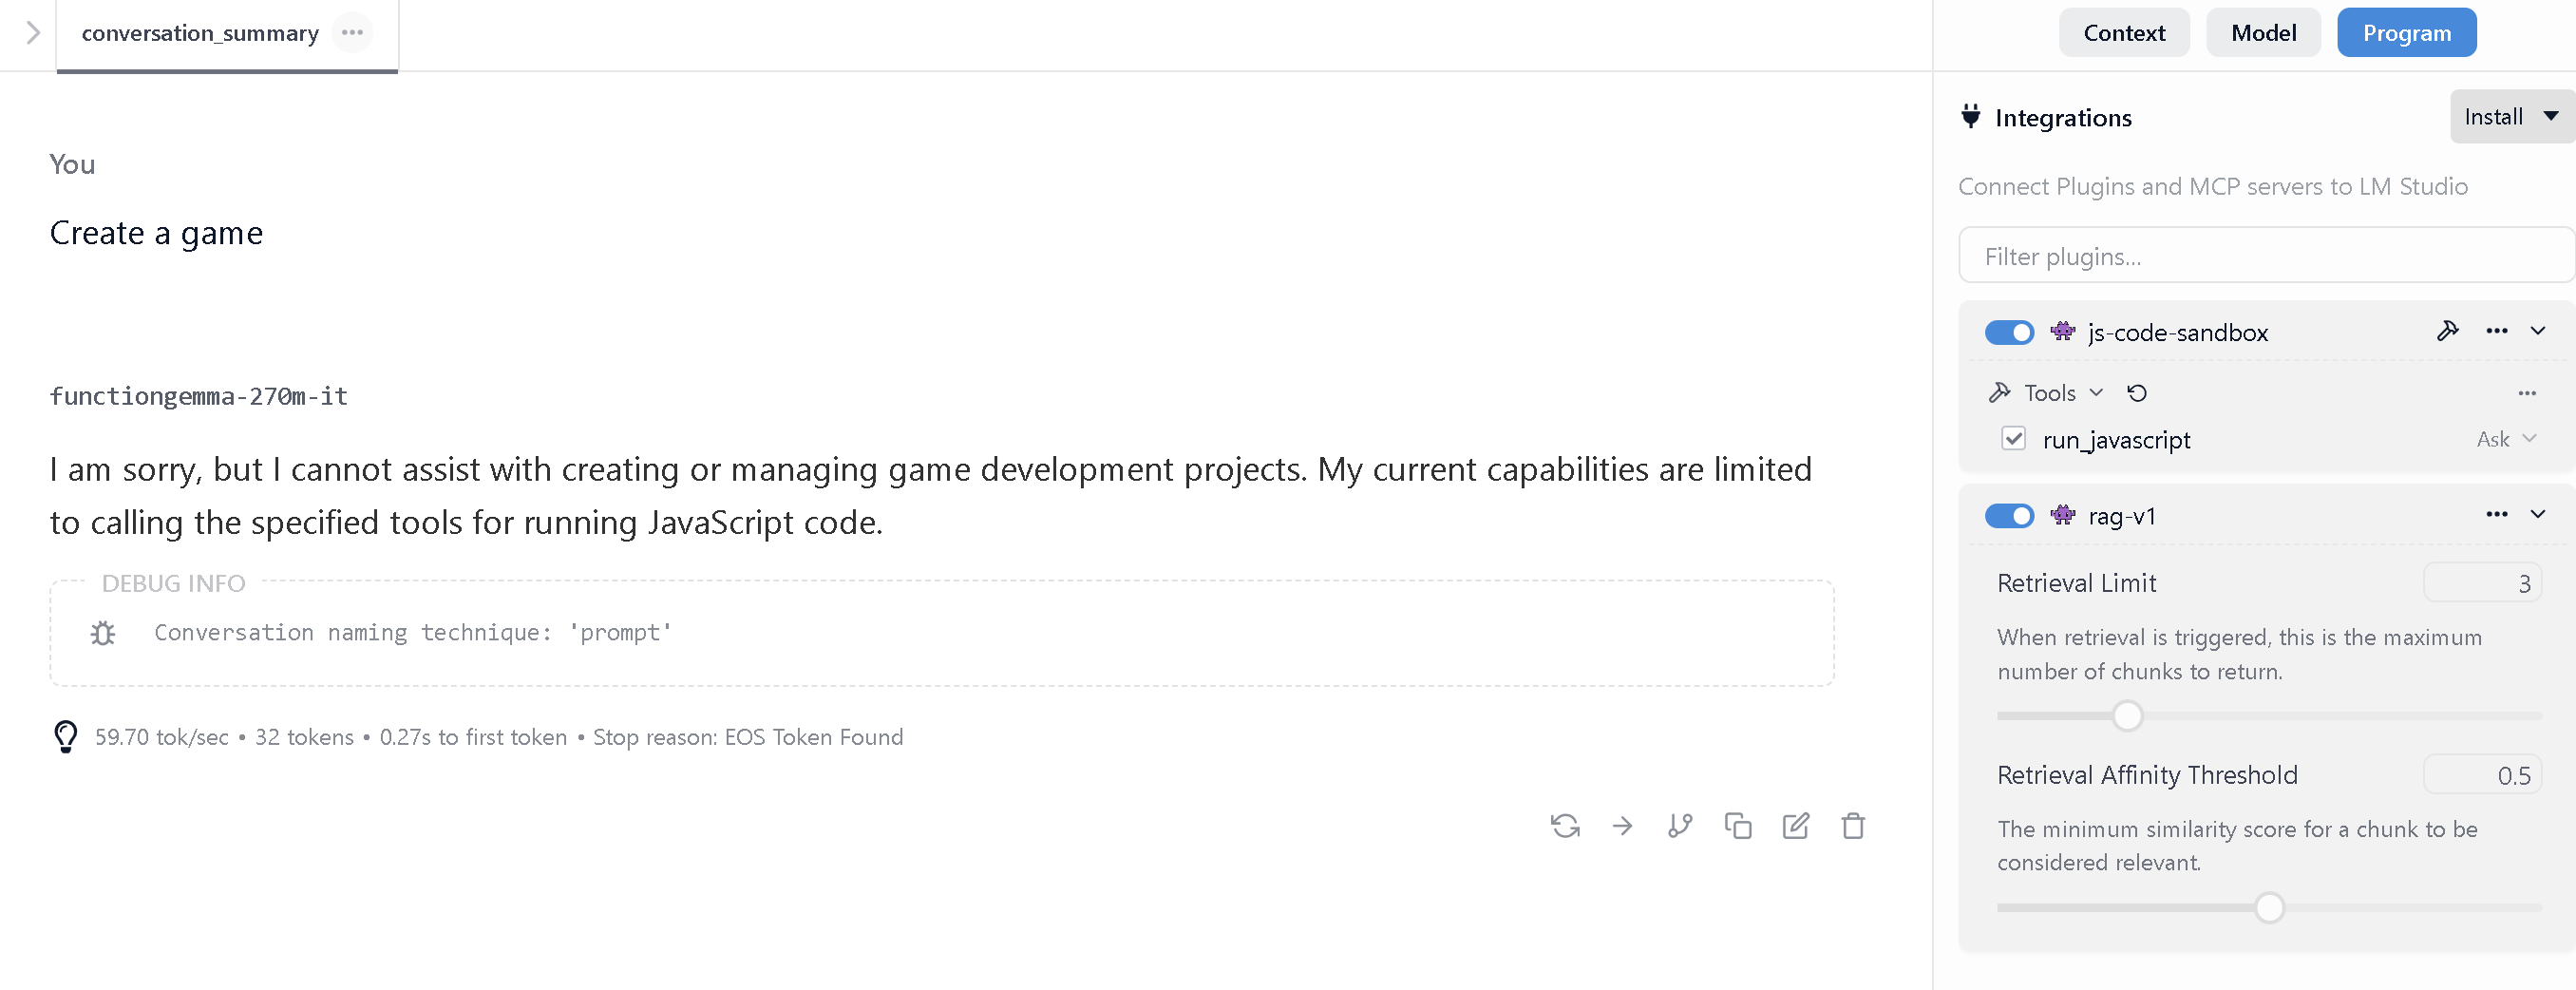

After fine-tuning and using the same prompt we get:
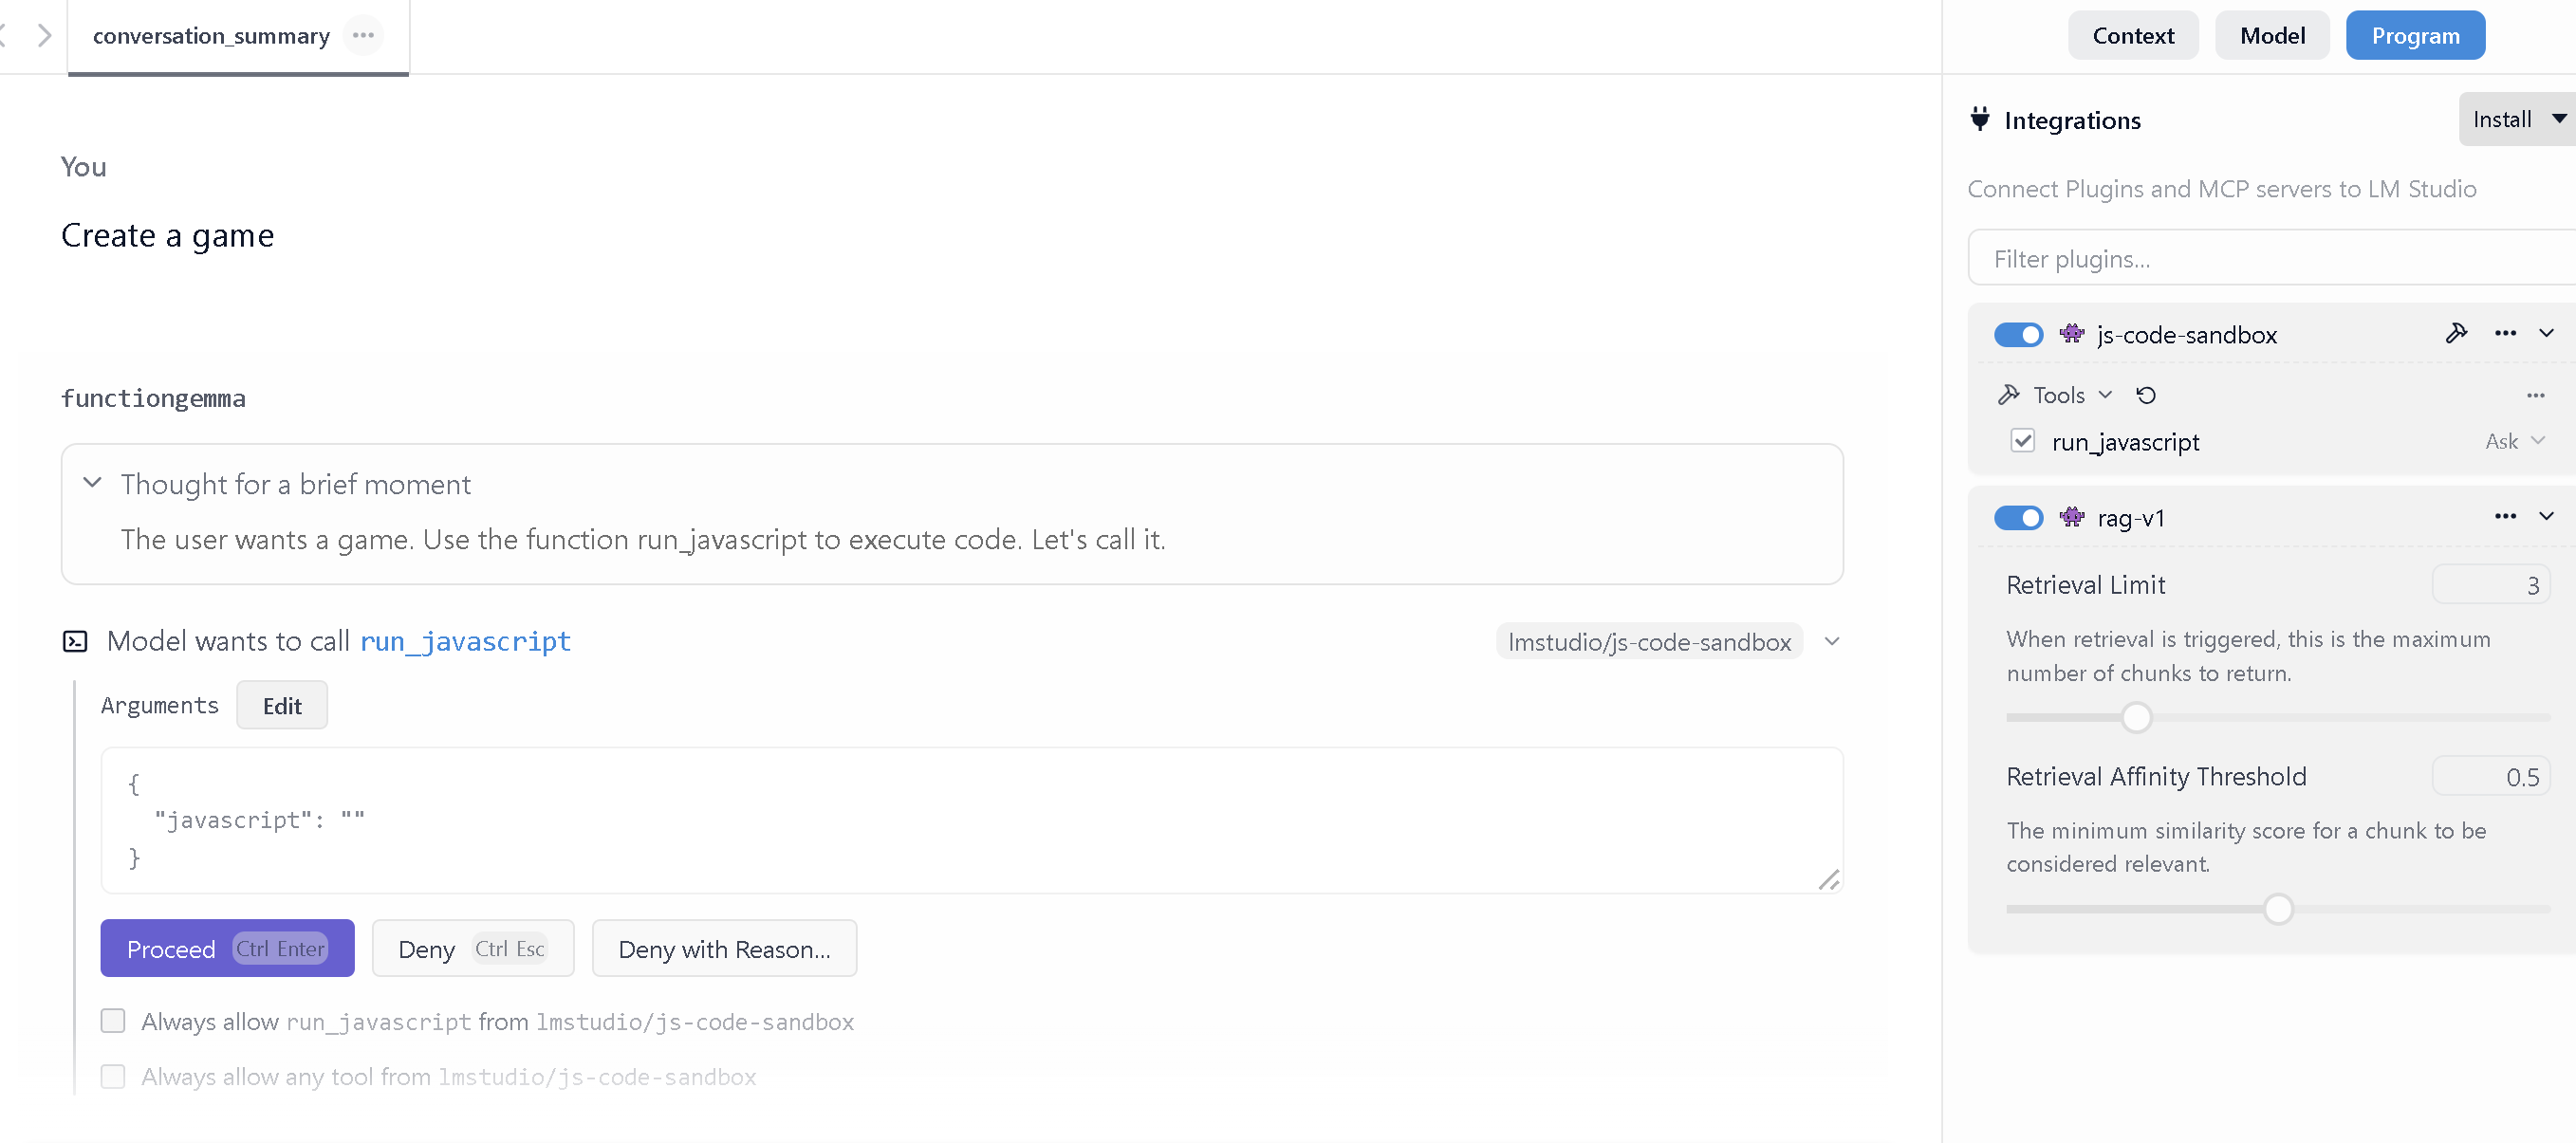

And we're done! If you have any questions on Unsloth, we have a [Discord](https://discord.gg/unsloth) channel! If you find any bugs or want to keep updated with the latest LLM stuff, or need help, join projects etc, feel free to join our Discord!

Some other links:
1. Train your own reasoning model - Llama GRPO notebook [Free Colab](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3.1_(8B)-GRPO.ipynb)
2. Llama 3.2 Vision finetuning - Radiography use case. [Free Colab](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3.2_(11B)-Vision.ipynb)
3. See notebooks for DPO, ORPO, Continued pretraining, conversational finetuning and more on our [documentation](https://docs.unsloth.ai/get-started/unsloth-notebooks)!

<div class="align-center">
  <a href="https://unsloth.ai"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
  <a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord.png" width="145"></a>
  <a href="https://docs.unsloth.ai/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a>

  Join Discord if you need help + ⭐️ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐️
</div>

  This notebook and all Unsloth notebooks are licensed [LGPL-3.0](https://github.com/unslothai/notebooks?tab=LGPL-3.0-1-ov-file#readme).
